# Test cross-reservoir: LSTM + PVT-encoder (Norne → Volve)

Entrenamos un LSTM seq-to-seq con encoder de PVT sobre **Norne** (30 simulaciones con variaciones del schedule de inyección de agua) y lo evaluamos contra **Volve**.

## 1. Setup


In [10]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
torch.manual_seed(42); np.random.seed(42)

NORNE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/dataset_norne.csv"
PVT_NORNE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/pvt_norne.csv"
VOLVE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/dataset_volve.csv"
PVT_VOLVE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/pvt_volve.csv"

PRESSURE_SCALE = 5000.0          # delta = (Pr - P_init) / PRESSURE_SCALE
M3_TO_BBL = 6.28981
TARGET = "Presion_Reservorio_psi"

STATIC_COLUMNS = ["Porosidad", "log10_Permeabilidad_mD", "P_initial_norm"]
DYNAMIC_COLUMNS = ["Np_over_PV", "Wp_over_PV", "Winj_over_PV", "GOR_cum",
                   "qo_over_PV", "qwinj_over_PV", "WOR_inst", "water_cut_cum", "VRR_simple"]


## 2. Datasets y feature engineering

Cargamos los dos datasets: **Norne** (30 sims, con variaciones solo en el schedule de inyección de agua) y **Volve** (10 sims, reservado exclusivamente para la evaluación cross-reservoir final).

A partir del schema crudo de 16 columnas (porosidad, permeabilidad, acumuladas, caudales, etc.) construimos **12 features adimensionales**. La adimensionalización es el truco que habilita el transfer cross-reservoir: dividimos las acumuladas (`Np`, `Wp`, `Winj`) por el _pore-volume_ del reservorio (el volumen total que podría llenarse con fluido) y los caudales por el mismo pore-volume. Así el modelo no aprende _"este campo lleva Np > 1e8 bbl"_ sino _"este campo ya recuperó X% de su volumen total"_.

Las features incluyen también GOR acumulado, WOR instantáneo, water-cut acumulado y un VRR (voidage replacement ratio) simplificado.

In [11]:
def build_features(raw_df):
    """Construye 12 features adimensionales (3 estaticos + 9 dinamicos) desde el schema crudo de 16 columnas.

    Estaticos por simulacion: porosidad, log10 permeabilidad, presion inicial normalizada.
    Dinamicos por timestep: cumuladas (Np, Wp, Winj) divididas por el pore-volume,
    GOR acumulado, caudales instantaneos sobre pore-volume, WOR instantaneo, water cut
    acumulado y VRR simplificado. La normalizacion por pore-volume saca la dependencia
    del tamano fisico del reservorio y hace que las features sean comparables entre
    Norne y Volve — pilar del transfer cross-reservoir.
    """
    features = pd.DataFrame({col: raw_df[col]
                             for col in ["sim_id", "reservoir_id", "tiempo_dias", TARGET]})
    pore_volume = raw_df["Area"] * raw_df["Espesor_Neto_m"] * raw_df["Porosidad"] * M3_TO_BBL

    features["Porosidad"] = raw_df["Porosidad"]
    features["log10_Permeabilidad_mD"] = np.log10(raw_df["Permeabilidad_mD"].clip(lower=1e-3))
    features["P_initial_norm"] = (raw_df.groupby(["reservoir_id", "sim_id"])[TARGET]
                                  .transform("first") / PRESSURE_SCALE)

    features["Np_over_PV"] = raw_df["Prod_Acumulada_Petroleo"] / pore_volume
    features["Wp_over_PV"] = raw_df["Prod_Acumulada_Agua"] / pore_volume
    features["Winj_over_PV"] = raw_df["Iny_Acumulada_Agua"] / pore_volume

    with np.errstate(divide="ignore", invalid="ignore"):
        features["GOR_cum"] = np.where(
            raw_df["Prod_Acumulada_Petroleo"] > 0,
            raw_df["Prod_Acumulada_Gas"] / raw_df["Prod_Acumulada_Petroleo"], 0.0)

    features["qo_over_PV"] = raw_df["Caudal_Prod_Petroleo_bbl"] / pore_volume
    features["qwinj_over_PV"] = raw_df["Caudal_Iny_Agua_bbl"] / pore_volume

    sim_groups = raw_df.groupby(["reservoir_id", "sim_id"])
    water_production_rate = (sim_groups["Prod_Acumulada_Agua"].diff()
                             / sim_groups["tiempo_dias"].diff().replace(0, np.nan))
    with np.errstate(divide="ignore", invalid="ignore"):
        features["WOR_inst"] = np.where(
            raw_df["Caudal_Prod_Petroleo_bbl"] > 0,
            water_production_rate / raw_df["Caudal_Prod_Petroleo_bbl"], 0.0)
        total_liquid_produced = raw_df["Prod_Acumulada_Petroleo"] + raw_df["Prod_Acumulada_Agua"]
        features["water_cut_cum"] = np.where(
            total_liquid_produced > 0,
            raw_df["Prod_Acumulada_Agua"] / total_liquid_produced, 0.0)
        features["VRR_simple"] = np.where(
            total_liquid_produced > 0,
            raw_df["Iny_Acumulada_Agua"] / total_liquid_produced, 0.0)
    return features.fillna(0.0)


norne_data = pd.read_csv(NORNE_URL)
volve_data = pd.read_csv(VOLVE_URL)
norne_features = build_features(norne_data)
volve_features = build_features(volve_data)
print(f"Norne features: {norne_features.shape}, sims={norne_features['sim_id'].nunique()}")
print(f"Volve features: {volve_features.shape}, sims={volve_features['sim_id'].nunique()}")


Norne features: (10580, 16), sims=30
Volve features: (4144, 16), sims=10


## 3. Tabla PVT del fluido

Cada reservorio contiene un fluido (mezcla de petróleo, gas y agua) cuyas propiedades termodinámicas cambian con la presión. Para predecir la evolución de `Pr` el modelo necesita _saber qué fluido tiene en frente_, y esa información vive en tres cantidades:

- **Bo** (oil formation volume factor): cuántos barriles ocupa _en fondo de pozo_ un barril de petróleo medido _en superficie_. Cuando la presión baja, el petróleo se expande y Bo cambia.
- **Bg** (gas formation volume factor): lo mismo para el gas.
- **Rs** (solution gas-oil ratio): cuánto gas viene disuelto en cada barril de petróleo a una presión dada. A más presión, más gas disuelto.

En la práctica, antes de empezar a producir un campo se toma una muestra del fluido del reservorio y se manda a un laboratorio. Allí, en un cilindro a temperatura controlada, se mide Bo, Bg y Rs a varias presiones (típicamente 17 puntos entre 1500 y 5500 psi). El resultado es la **tabla PVT** del campo: un conjunto de mediciones físicas que se conocen desde el día cero, **antes** de que arranque la producción, y que no dependen de la evolución posterior del reservorio. La almacenamos como un CSV de 4 columnas (`p_grid_psi, bo_rb_stb, bg_rb_scf, rs_scf_stb`) × 17 filas.

Hay una cuarta cantidad relevante en la física del reservorio, la **presión de burbuja** `Pb` — la presión a la cual el gas empieza a salirse del petróleo, marca un cambio en la dinámica de flujo. Pero `Pb` no hace falta como entrada extra: es exactamente la presión donde `Bo` alcanza su máximo (el "codo" de la curva), así que el encoder lo puede deducir de los 17 valores de Bo. Por eso no lo incluimos en el CSV.

### Cómo evitar leakear el target

Los datos termodinámicos `Bo`, `Bg` y `Rs` dependen de la presión del reservorio. En el dataset original se almacenan por timestep, ya evaluados a la presión de cada instante, pero esto es un error, ya que eso los convierte en proxies directos del target. Usarlos de esta forma sería leakage: cada valor revela la presión que el modelo tiene que predecir.

La solución es pasar **la tabla PVT entera** como un vector fijo por simulación, es decir, los 17 valores de cada curva, sin lookup dinámico. Así el modelo conoce cómo se comporta el fluido _a cualquier presión_, sin necesidad de saber a qué presión está el reservorio en el timestep actual.

### Encoding del vector PVT

Cada simulación se representa con un vector de **51 dimensiones** que concatena `[Bo×17, Bg×17, Rs×17]` (las tres curvas sobre los 17 puntos de presión). Las tablas de Norne y Volve están definidas sobre el mismo grid de presión (1500-5500 psi, 17 puntos), así que no hace falta interpolar. La tabla PVT se pasa como un parámetro explícito a la función que arma los tensores (sección 5).

In [ ]:
def build_pvt_vector(pvt_table_df):
    """Construye el vector PVT de 51D que ve el encoder: [Bo·17, Bg·17·1000, Rs·17/1000].

    Bo, Bg, Rs son las tres curvas medidas en el laboratorio (17 puntos cada una).
    El re-escalado por 1000 / 1/1000 hace que las tres curvas vivan en ordenes de
    magnitud comparables antes de entrar al encoder (Bo ~ O(1), Bg sin escalar ~ O(1e-3),
    Rs sin escalar ~ O(1e3)).

    Nota: la columna `p_grid_psi` no se lee — el grid de presiones queda implicito
    por posicion (slot i = i-esima presion del grid canonico 1500-5500 psi del
    training). Si la tabla de entrada no respeta ese grid hay que interpolarla antes.
    """
    oil_volume_factor = pvt_table_df["bo_rb_stb"].to_numpy()
    gas_volume_factor = pvt_table_df["bg_rb_scf"].to_numpy() * 1000.0
    solution_gas_ratio = pvt_table_df["rs_scf_stb"].to_numpy() / 1000.0
    return np.concatenate([oil_volume_factor, gas_volume_factor,
                           solution_gas_ratio]).astype(np.float32)


norne_pvt_table = pd.read_csv(PVT_NORNE_URL)
volve_pvt_table = pd.read_csv(PVT_VOLVE_URL)
print(f"PVT vector dim: {len(build_pvt_vector(norne_pvt_table))}")
print(f"Norne PVT table: {norne_pvt_table.shape}")
print(f"Volve PVT table: {volve_pvt_table.shape}")

## 4. Modelo

**Arquitectura**: LSTM seq-to-seq de 2 capas (hidden=64). El input principal son los 9 features dinámicos por timestep, pero además el modelo recibe dos vectores _contextuales_ que valen para toda la simulación:

- 3 features estáticos (porosidad, log10 permeabilidad, presión inicial normalizada).
- 1 vector PVT de 51 dimensiones (la tabla de laboratorio que armamos en la sección 3).

**¿Por qué un encoder para el PVT (y otro para los estáticos)?** El vector PVT vive en 51 dimensiones. Concatenarlo directamente con los 9 features dinámicos en cada timestep tiene tres problemas:

1. **Dilución de señal**: 51 dimensiones constantes vs 9 que cambian — el gradiente que viene del target tendería a ignorar las constantes y el LSTM no aprovecharía la información del fluido.
2. **Desperdicio de capacidad**: el LSTM tendría que aprender por sí solo qué dimensiones de la tabla son informativas para predecir Pr. Es una tarea de compresión casi estática que un MLP simple resuelve mejor.
3. **Overfitting**: el `input_size` del LSTM crecería de 41 (= 9 + 2×16) a 60, casi 50% más parámetros — riesgoso con un dataset chico (30 sims).

El MLP encoder hace ese trabajo de compresión por adelantado: aprende a destilar las 51 dimensiones de la tabla PVT a un embedding de 16 dimensiones que captura solo lo útil para la dinámica de presión. Lo mismo con el encoder estático (3D → 16D). Los dos embeddings se concatenan en un contexto de 32D, se broadcastean a cada timestep, y recién ahí se concatenan con los 9 features dinámicos antes de entrar al LSTM. La cabeza es un MLP pequeño que emite el delta target normalizado en cada timestep.

**Cómo viaja la información del PVT a la predicción sin leakear**: el encoder consume el vector PVT _constante_ de la simulación (51 dims, mediciones de laboratorio que no dependen de Pr en ningún momento) y lo entrega como un contexto fijo que el LSTM ve igual en todos los timesteps. La información termodinámica del fluido entra a la predicción, pero la presión actual no — el modelo nunca tiene acceso al target.

In [13]:
class LSTMPVT(nn.Module):
    """LSTM seq-to-seq con dos MLP encoders (uno para PVT y otro para features estaticos) que aportan contexto por sim.

    Flow del forward: el PVT (51D) pasa por su encoder y sale como vector 16D; los
    estaticos (3D) hacen lo mismo. Los dos embeddings se concatenan (-> 32D) y se
    broadcastean a cada timestep, donde se concatenan con los features dinamicos (9D)
    antes de entrar al LSTM (input_size = 9 + 32 = 41, hidden = 64, 2 layers). La head
    es un MLP pequeno que emite el delta target normalizado (Pr - P_init) / PRESSURE_SCALE
    en cada timestep.
    """
    def __init__(self, n_dynamic=9, n_static=3, pvt_dim=51, context_dim=16,
                 hidden_size=64, num_layers=2, dropout=0.15):
        super().__init__()
        self.pvt_encoder = nn.Sequential(
            nn.Linear(pvt_dim, 32), nn.GELU(), nn.Linear(32, context_dim))
        self.static_encoder = nn.Sequential(
            nn.Linear(n_static, 16), nn.GELU(), nn.Linear(16, context_dim))
        self.lstm = nn.LSTM(n_dynamic + 2 * context_dim, hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden_size, 32), nn.GELU(), nn.Linear(32, 1))

    def forward(self, dynamic_features, static_features, pvt_vector):
        pvt_context = self.pvt_encoder(pvt_vector)
        static_context = self.static_encoder(static_features)
        context = torch.cat([pvt_context, static_context], dim=-1)
        context_per_timestep = context.unsqueeze(1).expand(-1, dynamic_features.shape[1], -1)
        lstm_input = torch.cat([dynamic_features, context_per_timestep], dim=-1)
        lstm_output, _ = self.lstm(lstm_input)
        return self.head(lstm_output).squeeze(-1)


## 5. Split, tensorización y entrenamiento

**Splits**: las 30 sims de Norne se dividen en 24 train y 6 test (80/20 por sim_id). Volve queda completamente fuera del training y se reserva para la sección 7. No tenemos un split de validación porque el modelo se entrena con una receta fija (30 epochs, cosine LR schedule) que ya fue elegida con experimentos previos — no hay hiperparámetros para tunear en este run.

**Z-score**: se ajustan dos `StandardScaler` (uno para dinámicas, otro para estáticas) **solo sobre train** — usar test o Volve para ajustar las medias y desvíos sería leakage. El scaler entrenado se aplica después a los otros splits.

**Padding**: las simulaciones tienen distinto número de timesteps. Usamos `torch.nn.utils.rnn.pad_sequence` para apilarlas en un tensor batched y una `mask` boolean para indicar qué timesteps son reales vs padding — la mask se multiplica al MSE para que el padding no contribuya a la loss.

**`prepare_dataset` recibe la tabla PVT como parámetro**: el dataset de presiones (las features adimensionales) y la tabla PVT del laboratorio son dos entradas separadas. La función arma el vector PVT una vez desde la tabla pasada como argumento y lo replica para todas las simulaciones del split. Los splits de Norne reciben `norne_pvt_table`; Volve recibe `volve_pvt_table`.

**Entrenamiento**: 30 epochs fijos, optimizador AdamW (lr=1e-3, wd=1e-4) y `CosineAnnealingLR` con `T_max=30`. El cosine schedule baja la learning rate de 1e-3 a ~0 a lo largo del entrenamiento — actúa como _regularización temporal_ natural y previene la divergencia tardía que se observa en runs largos sin schedule.

In [14]:
TRAIN_SIMS = list(range(1, 25))   # sims 1..24 (24 sims)
TEST_SIMS = list(range(25, 31))   # sims 25..30 (6 sims)

train_features = norne_features[norne_features["sim_id"].isin(TRAIN_SIMS)]
test_features = norne_features[norne_features["sim_id"].isin(TEST_SIMS)]

scaler_dynamic = StandardScaler().fit(train_features[DYNAMIC_COLUMNS])
scaler_static = StandardScaler().fit(train_features.groupby("sim_id").first()[STATIC_COLUMNS])


def prepare_dataset(features_df, pvt_table_df):
    """Empaqueta el dataset de presiones + tabla PVT en tensores padded y devuelve (X, y) listos para el modelo.

    Parametros
    ----------
    features_df : DataFrame
        Features adimensionales por timestep para una o mas simulaciones (todas las
        sims de este dataframe comparten el mismo reservorio y por lo tanto el mismo PVT).
    pvt_table_df : DataFrame
        Tabla PVT del laboratorio del reservorio correspondiente (17 filas × 4 columnas:
        p_grid_psi, bo_rb_stb, bg_rb_scf, rs_scf_stb).

    Por cada sim:
      - normaliza los features dinamicos y estaticos con los scalers ya ajustados en train,
      - calcula el delta target (Pr - P_init) / PRESSURE_SCALE timestep a timestep,
      - guarda el array de Pr crudo en `true_pressures` para denormalizar despues al evaluar.
    El vector PVT se calcula una sola vez desde `pvt_table_df` y se replica para todas
    las simulaciones del split. Todas las sims se padean al T_max via `pad_sequence`;
    la `mask` indica timesteps reales vs padding (se usa luego para enmascarar la loss).

    Returns
    -------
    X : dict con los inputs del modelo (dynamic_features, static_features, pvt_vector).
    y : dict con el target y la metadata necesaria para evaluar y plotear
        (delta_target, mask, initial_pressure, true_pressures, sim_ids).
    """
    simulations = list(features_df.groupby("sim_id", sort=True))

    dynamic_features = pad_sequence(
        [torch.tensor(scaler_dynamic.transform(sim_data[DYNAMIC_COLUMNS]), dtype=torch.float32)
         for _, sim_data in simulations], batch_first=True)
    static_features = torch.tensor(
        scaler_static.transform(np.stack([sim_data[STATIC_COLUMNS].iloc[0]
                                          for _, sim_data in simulations])),
        dtype=torch.float32)

    # Build the PVT vector once from the table and broadcast it to every sim.
    pvt_vector_template = build_pvt_vector(pvt_table_df)
    pvt_vector = torch.tensor(np.stack([pvt_vector_template] * len(simulations)))

    initial_pressure = torch.tensor(
        [sim_data["P_initial_norm"].iloc[0] * PRESSURE_SCALE for _, sim_data in simulations],
        dtype=torch.float32)
    true_pressures = [sim_data[TARGET].to_numpy() for _, sim_data in simulations]
    delta_target = pad_sequence(
        [torch.tensor((pressures - p_init.item()) / PRESSURE_SCALE, dtype=torch.float32)
         for pressures, p_init in zip(true_pressures, initial_pressure)],
        batch_first=True)
    sequence_lengths = torch.tensor([len(sim_data) for _, sim_data in simulations])
    mask = (torch.arange(dynamic_features.shape[1])[None, :] < sequence_lengths[:, None]).float()

    X = {"dynamic_features": dynamic_features,
         "static_features": static_features,
         "pvt_vector": pvt_vector}
    y = {"delta_target": delta_target,
         "mask": mask,
         "initial_pressure": initial_pressure,
         "true_pressures": true_pressures,
         "sim_ids": [int(sim_id) for sim_id, _ in simulations]}
    return X, y


X_train, y_train = prepare_dataset(train_features, norne_pvt_table)
X_test, y_test = prepare_dataset(test_features, norne_pvt_table)

model = LSTMPVT(n_dynamic=len(DYNAMIC_COLUMNS), n_static=len(STATIC_COLUMNS),
                pvt_dim=X_train["pvt_vector"].shape[1])
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
mse_loss = nn.MSELoss(reduction="none")

for epoch in range(30):
    model.train()
    predictions = model(X_train["dynamic_features"],
                        X_train["static_features"],
                        X_train["pvt_vector"])
    squared_errors = mse_loss(predictions, y_train["delta_target"])
    loss = (squared_errors * y_train["mask"]).sum() / y_train["mask"].sum()
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
model.eval()
print(f"final training delta-MSE: {loss.item():.5f}")


final training delta-MSE: 0.00022


## 6. Norne — evaluación sobre test

Métricas `R²` y `MAE` sobre las 6 sims de test (fold-out por sim_id, dentro de la distribución Norne). Como referencia, un baseline _naive_ que siempre predice `P_init` da MAE ~80 psi sobre Norne — los schedule variants mueven la presión solo ~100-200 psi, así que es un baseline relativamente fuerte para superar.

In [15]:
@torch.no_grad()
def predict_pressures(X, y):
    """Corre el modelo, denormaliza delta -> psi y devuelve `true` y `predicted` como listas por simulacion.

    El modelo emite el delta normalizado `(Pr - P_init) / PRESSURE_SCALE`; aca lo
    multiplicamos por PRESSURE_SCALE y le sumamos la presion inicial para volver a psi.
    Cada elemento de la lista tiene la longitud real de su simulacion (sin padding).
    """
    delta_predictions = model(X["dynamic_features"],
                              X["static_features"],
                              X["pvt_vector"]).numpy()
    initial_pressure = y["initial_pressure"].numpy()
    pressures_predicted = [initial_pressure[i] + delta_predictions[i, :len(pressures)] * PRESSURE_SCALE
                           for i, pressures in enumerate(y["true_pressures"])]
    return y["true_pressures"], pressures_predicted


def evaluate(X, y, name):
    """Corre el modelo sobre un split empaquetado y devuelve una Serie pandas con R² y MAE."""
    pressures_true_per_sim, pressures_pred_per_sim = predict_pressures(X, y)
    pressures_true = np.concatenate(pressures_true_per_sim)
    pressures_pred = np.concatenate(pressures_pred_per_sim)
    return pd.Series({
        "sims": len(pressures_true_per_sim),
        "rows": len(pressures_true),
        "R²": round(r2_score(pressures_true, pressures_pred), 4),
        "MAE (psi)": round(mean_absolute_error(pressures_true, pressures_pred), 1),
    }, name=name)


pd.DataFrame([evaluate(X_train, y_train, "Norne train (in-sample)"),
              evaluate(X_test, y_test, "Norne test")])


,sims,rows,R²,MAE (psi)
Norne train (in-sample),24.0,8444.0,0.8838,58.1
Norne test,6.0,2136.0,0.9077,53.4


## 7. Volve — evaluación cross-reservoir

Volve nunca se vio durante el training. **Campo distinto, PVT distinto, geometría distinta, presión inicial distinta**. La pregunta clave del experimento es si el modelo aprendió la _física_ subyacente (cómo evoluciona `Pr` en función de extracción/inyección y propiedades del fluido) o si solo memorizó la distribución específica de Norne.

**Lo que carga el transfer**: los features adimensionales se encargan de las diferencias geométricas y de escala entre los dos campos; el PVT-encoder es lo que le dice al modelo _"este reservorio tiene otro fluido"_, permitiéndole condicionar sus predicciones al PVT específico de Volve aunque nunca lo haya visto. En este caso pasamos `volve_pvt_table` como parámetro PVT al `prepare_dataset`.

Como referencia, un baseline _naive_ que siempre predice `P_init` da MAE ≈ 197 psi y R² ≈ +0.22 sobre Volve. Cualquier número significativamente mejor implica que el modelo realmente está modelando la depleción/repesurización del reservorio.

In [16]:
X_volve, y_volve = prepare_dataset(volve_features, volve_pvt_table)
pd.DataFrame([evaluate(X_volve, y_volve, "Volve (cross-reservoir)")])

,sims,rows,R²,MAE (psi)
Volve (cross-reservoir),10.0,4144.0,0.7375,107.5


## 8. Plots — Pr real vs predicha

Visualizamos qué tan bien el modelo captura la trayectoria de presión por simulación. Para cada split (Norne test y Volve) se muestran dos vistas:

1. **Trayectorias por simulación**: la presión real (línea negra) y la presión predicha por el modelo (línea azul punteada) a lo largo del tiempo. Permite ver si el modelo está siguiendo la dinámica de depleción o solo prediciendo un valor constante.
2. **Parity plot**: scatter de Pr real vs Pr predicha sobre todos los timesteps del split. La diagonal `y = x` representa la predicción perfecta. Cuanto más compacto el grupo de puntos alrededor de la diagonal, mejor es el ajuste.

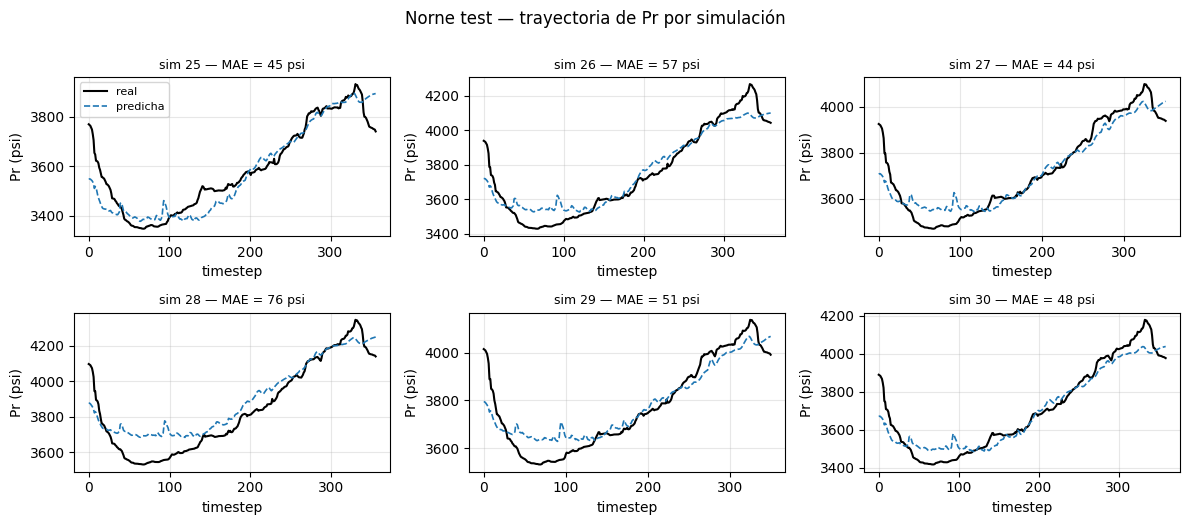

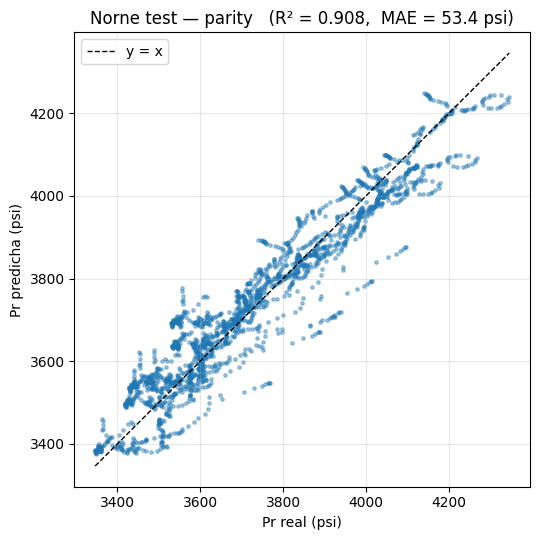

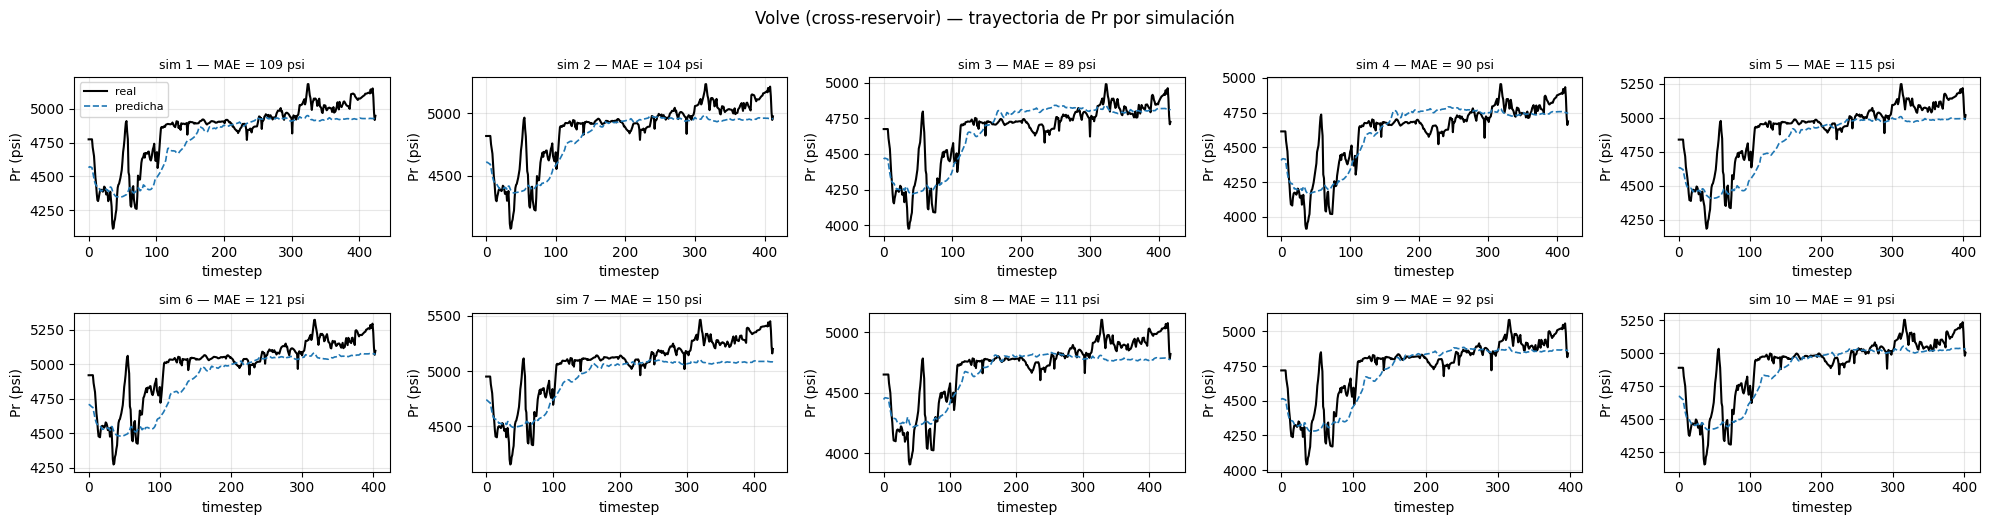

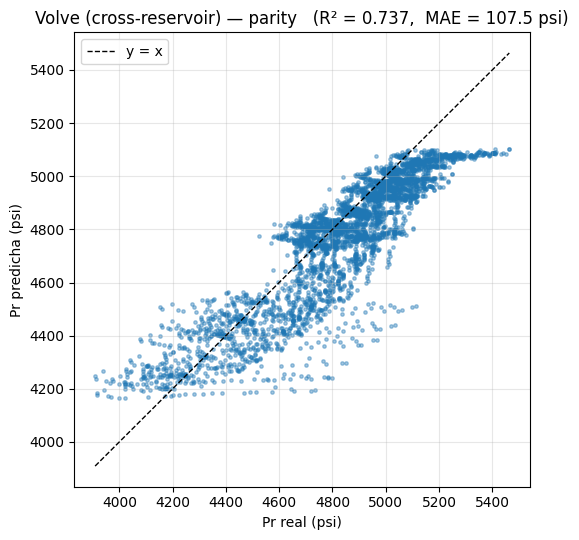

In [17]:
def plot_trajectories(X, y, title, n_cols=3):
    """Plotea Pr real vs Pr predicha por simulacion en un grid, con MAE por panel."""
    pressures_true_per_sim, pressures_pred_per_sim = predict_pressures(X, y)
    sim_ids = y["sim_ids"]
    n_sims = len(pressures_true_per_sim)
    n_rows = (n_sims + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2.6))
    axes_list = list(axes.flat) if hasattr(axes, "flat") else [axes]
    for i, (pressures_true, pressures_pred, ax) in enumerate(
            zip(pressures_true_per_sim, pressures_pred_per_sim, axes_list)):
        ax.plot(pressures_true, color="black", lw=1.5, label="real")
        ax.plot(pressures_pred, color="C0", lw=1.2, linestyle="--", label="predicha")
        mae_sim = mean_absolute_error(pressures_true, pressures_pred)
        ax.set_title(f"sim {sim_ids[i]} — MAE = {mae_sim:.0f} psi", fontsize=9)
        ax.set_xlabel("timestep")
        ax.set_ylabel("Pr (psi)")
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8)
    for ax in axes_list[n_sims:]:
        ax.set_visible(False)
    fig.suptitle(f"{title} — trayectoria de Pr por simulación", y=1.00)
    plt.tight_layout()
    plt.show()


def plot_parity(X, y, title):
    """Plotea Pr real vs Pr predicha como scatter, con la diagonal y = x de referencia."""
    pressures_true_per_sim, pressures_pred_per_sim = predict_pressures(X, y)
    pressures_true = np.concatenate(pressures_true_per_sim)
    pressures_pred = np.concatenate(pressures_pred_per_sim)

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(pressures_true, pressures_pred, s=6, alpha=0.4, color="C0")
    lo = min(pressures_true.min(), pressures_pred.min())
    hi = max(pressures_true.max(), pressures_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
    mae_total = mean_absolute_error(pressures_true, pressures_pred)
    r2_total = r2_score(pressures_true, pressures_pred)
    ax.set_xlabel("Pr real (psi)")
    ax.set_ylabel("Pr predicha (psi)")
    ax.set_title(f"{title} — parity   (R² = {r2_total:.3f},  MAE = {mae_total:.1f} psi)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_trajectories(X_test, y_test, "Norne test")
plot_parity(X_test, y_test, "Norne test")

plot_trajectories(X_volve, y_volve, "Volve (cross-reservoir)", n_cols=5)
plot_parity(X_volve, y_volve, "Volve (cross-reservoir)")
